# Exploratory Data Analysis — Spotify Track Popularity

This notebook explores the combined Spotify track dataset (`data/raw/track_data_final.csv`,
produced by concatenating and de-duplicating two raw source extracts) before it enters the
production pipeline in `src/spotify_popularity/`.

**Goals**
1. Understand the shape, types and quality of the raw data.
2. Quantify missing values, duplicates and outliers.
3. Understand the distribution of the target, `track_popularity`.
4. Explore relationships between candidate features and the target.
5. Translate these findings into the feature-engineering decisions implemented in
   `src/spotify_popularity/components/feature_engineering.py` and
   `data_transformation.py`.


In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", 50)


## 1. Load the combined raw dataset

In [2]:
df = pd.read_csv("../data/raw/track_data_final.csv")
print("Shape:", df.shape)
df.head()


Shape: (8494, 15)


,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,5N3hjp1WNayUPZrA8kJmJP,Please Please Please,1,79,186000,True,Sabrina Carpenter,91.0,26516295.0,pop,5bBaoign62r1i7OV8w7mi9,Please Please Please,2024-06-06,2,single
1,2Iv2LfBnh1oNKqqTg8AaSY,YAD,1,0,180600,True,Vanna Rainelle,57.0,90428.0,dark r&b,1W5QaW8DYaanSuhqGAb3S7,YAD,2024-06-07,1,single
2,5c9tBmJKbTdn1vhzXHeAwW,Sympathy is a knife,3,74,150600,True,Charli xcx,82.0,6322030.0,"hyperpop, art pop",2lIZef4lzdvZkiiCzvPKj7,BRAT,2024-06-07,15,album
3,62fqMvguJbsSs9HKhhRfuS,Talk talk,5,68,161400,False,Charli xcx,82.0,6315216.0,"hyperpop, art pop",2lIZef4lzdvZkiiCzvPKj7,BRAT,2024-06-07,15,album
4,3Y1EvIgEVw51XtgNEgpz5c,Von dutch,6,79,163800,True,Charli xcx,82.0,6318755.0,"hyperpop, art pop",2lIZef4lzdvZkiiCzvPKj7,BRAT,2024-06-07,15,album


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8494 non-null   object 
 1   track_name          8492 non-null   object 
 2   track_number        8494 non-null   int64  
 3   track_popularity    8494 non-null   int64  
 4   track_duration_ms   8494 non-null   int64  
 5   explicit            8494 non-null   bool   
 6   artist_name         8491 non-null   object 
 7   artist_popularity   8494 non-null   float64
 8   artist_followers    8494 non-null   float64
 9   artist_genres       8491 non-null   object 
 10  album_id            8494 non-null   object 
 11  album_name          8492 non-null   object 
 12  album_release_date  8494 non-null   object 
 13  album_total_tracks  8494 non-null   int64  
 14  album_type          8494 non-null   object 
dtypes: bool(1), float64(2), int64(4), object(8)
memory usag

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,8494,8494,5N3hjp1WNayUPZrA8kJmJP,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,8492,7465,Home,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_number,8494.0,NaN,NaN,NaN,5.786202,6.068312,1.0,1.0,4.0,9.0,102.0
track_popularity,8494.0,NaN,NaN,NaN,52.193431,23.802331,0.0,39.0,58.0,71.0,99.0
track_duration_ms,8494.0,NaN,NaN,NaN,209488.873087,63753.394005,0.0,172800.0,206400.0,239196.5,810600.0
explicit,8494,2,False,6358,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist_name,8491,2548,Taylor Swift,321,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artist_popularity,8494.0,NaN,NaN,NaN,69.586296,19.714542,0.0,59.0,74.0,84.0,100.0
artist_followers,8494.0,NaN,NaN,NaN,23838885.370144,37951867.92367,0.0,442151.75,5976066.5,27139342.0,145542136.0
artist_genres,8491,816,[],3450,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data quality checks

### 2.1 Missing values

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report[missing_report.missing_count > 0]


,missing_count,missing_pct
artist_name,3,0.04
artist_genres,3,0.04
track_name,2,0.02
album_name,2,0.02


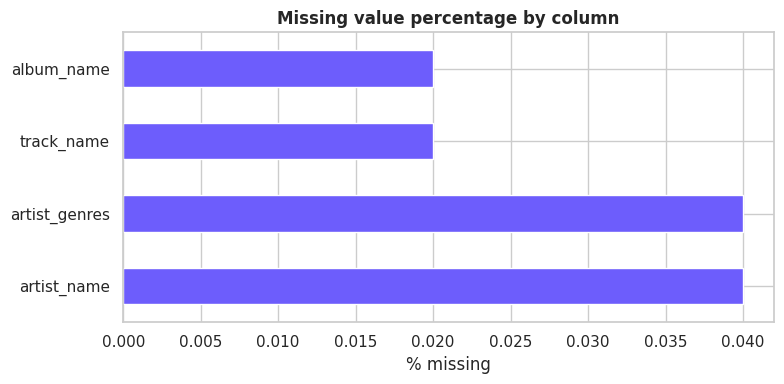

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_report[missing_report.missing_count > 0]["missing_pct"].plot(kind="barh", ax=ax, color="#6d5dfc")
ax.set_title("Missing value percentage by column")
ax.set_xlabel("% missing")
plt.tight_layout()
plt.show()


**Finding:** Null rates are low (well under 1% for most columns). `artist_genres`
has the highest null share among the columns that carry any nulls at all.
These are handled by a `most_frequent` imputer for categoricals and `median` imputer
for numerics inside `SpotifyPreprocessor` (see `data_transformation.py`).

### 2.2 Duplicate records

In [7]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated track_id:", df['track_id'].duplicated().sum())
print("Duplicated (track_name, artist_name, album_name, track_number):",
      df.duplicated(subset=['track_name', 'artist_name', 'album_name', 'track_number']).sum())


Fully duplicated rows: 0
Duplicated track_id: 0
Duplicated (track_name, artist_name, album_name, track_number): 0


**Finding:** The ingestion stage already de-duplicates on `track_id` and on the
`(track_name, artist_name, album_name, track_number)` composite key when merging the two
raw source files, so no further row-level de-duplication is required downstream — but
`DataTransformation._clean()` still runs a defensive `drop_duplicates()` in production.

## 3. Target variable — `track_popularity`

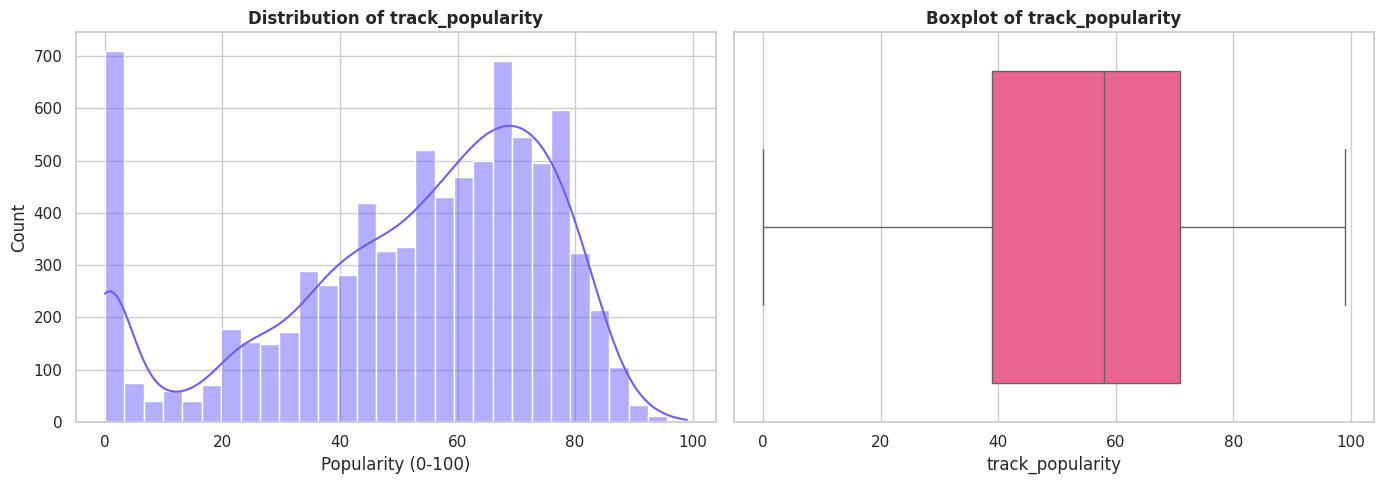

count    8494.000000
mean       52.193431
std        23.802331
min         0.000000
25%        39.000000
50%        58.000000
75%        71.000000
max        99.000000
Name: track_popularity, dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["track_popularity"], bins=30, kde=True, ax=axes[0], color="#6d5dfc")
axes[0].set_title("Distribution of track_popularity")
axes[0].set_xlabel("Popularity (0-100)")

sns.boxplot(x=df["track_popularity"], ax=axes[1], color="#ff4d8d")
axes[1].set_title("Boxplot of track_popularity")

plt.tight_layout()
plt.show()

df["track_popularity"].describe()


**Finding:** `track_popularity` is roughly bell-shaped with a long left tail toward 0
(a sizeable group of tracks with near-zero popularity — typically deep-catalog or very new
releases). The median sits around the high-50s, meaning most tracks in this dataset are from
artists/albums popular enough to be captured by the Spotify catalog scrape.

## 4. Numeric feature distributions & outliers

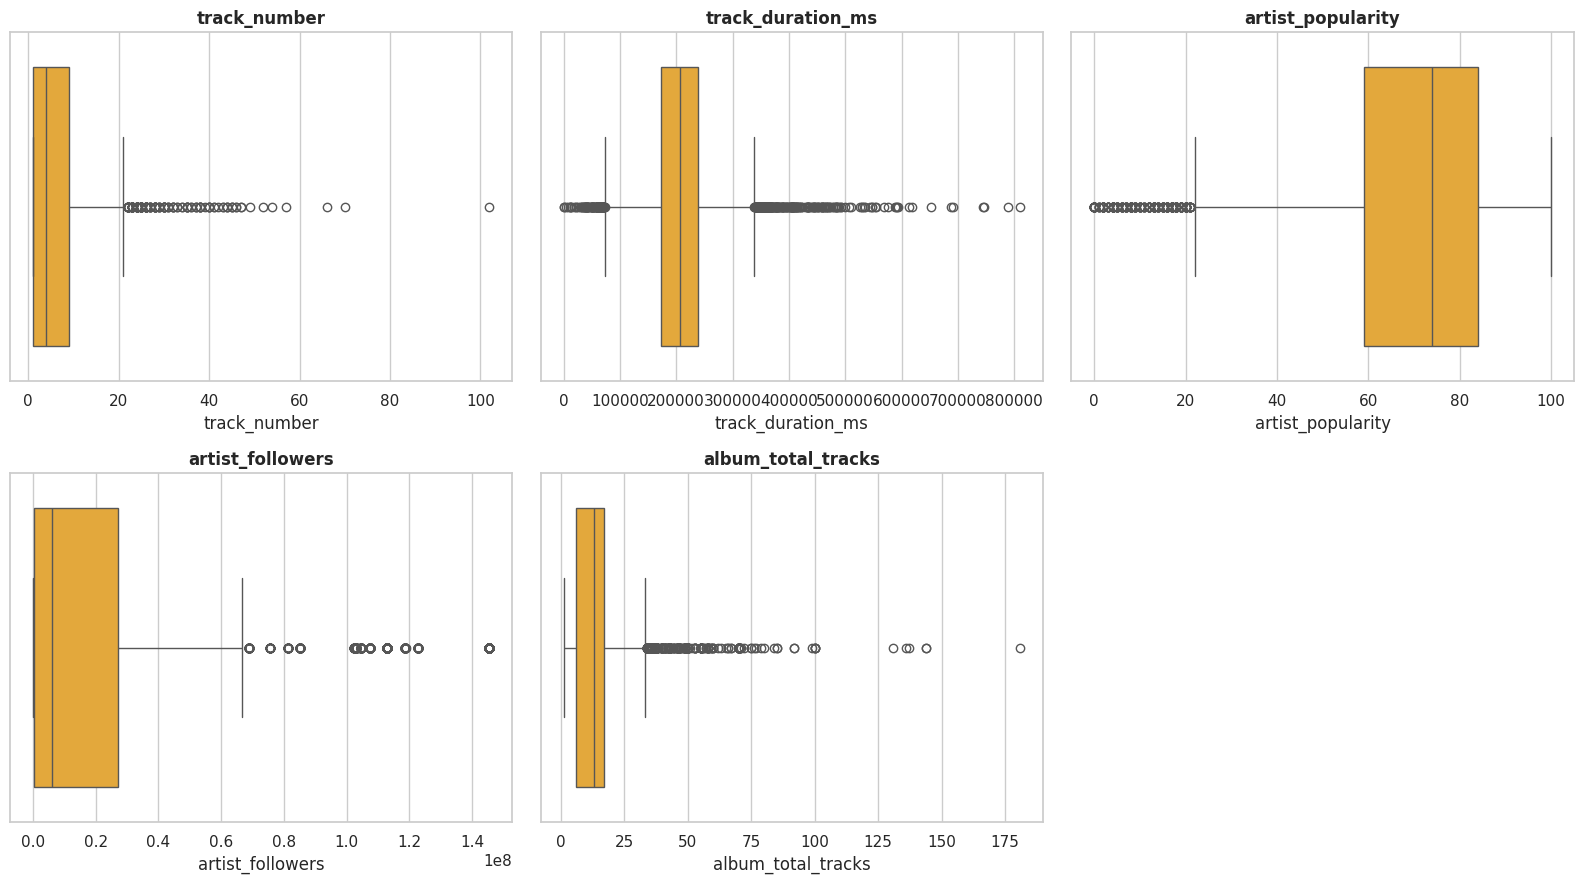

In [9]:
numeric_cols = ["track_number", "track_duration_ms", "artist_popularity",
                 "artist_followers", "album_total_tracks"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color="#ffb020")
    axes[i].set_title(col)
axes[-1].axis("off")
plt.tight_layout()
plt.show()


**Finding:** `artist_followers`, `track_duration_ms` and `album_total_tracks` all show
heavy right-skew with a long tail of extreme outliers (a handful of superstar artists with
100M+ followers, and a few compilation albums with 100+ tracks). This motivates:
- a `log1p` transform on `artist_followers` (see `FeatureEngineer`), and
- IQR-based outlier capping on all numeric features inside `OutlierCapper`
  (`data_transformation.py`) before scaling.

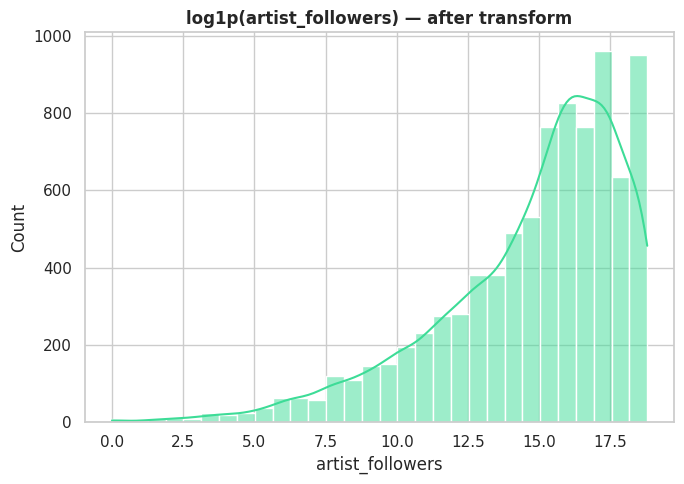

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.histplot(np.log1p(df["artist_followers"]), bins=30, kde=True, ax=ax, color="#3ddc97")
ax.set_title("log1p(artist_followers) — after transform")
plt.tight_layout()
plt.show()


## 5. Categorical features

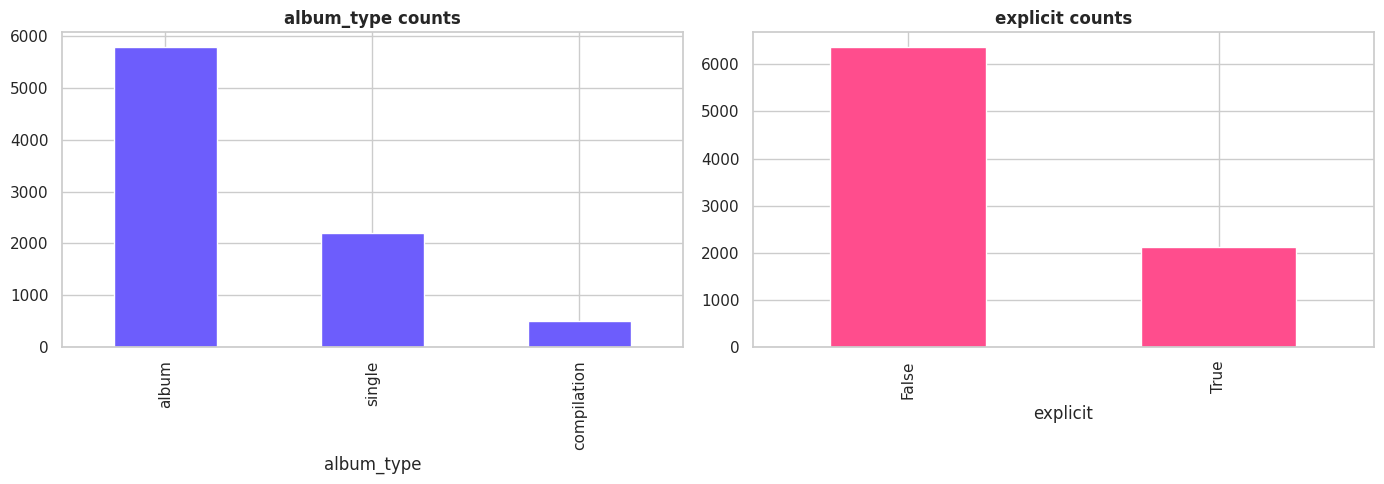

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["album_type"].value_counts().plot(kind="bar", ax=axes[0], color="#6d5dfc")
axes[0].set_title("album_type counts")

df["explicit"].value_counts().plot(kind="bar", ax=axes[1], color="#ff4d8d")
axes[1].set_title("explicit counts")

plt.tight_layout()
plt.show()


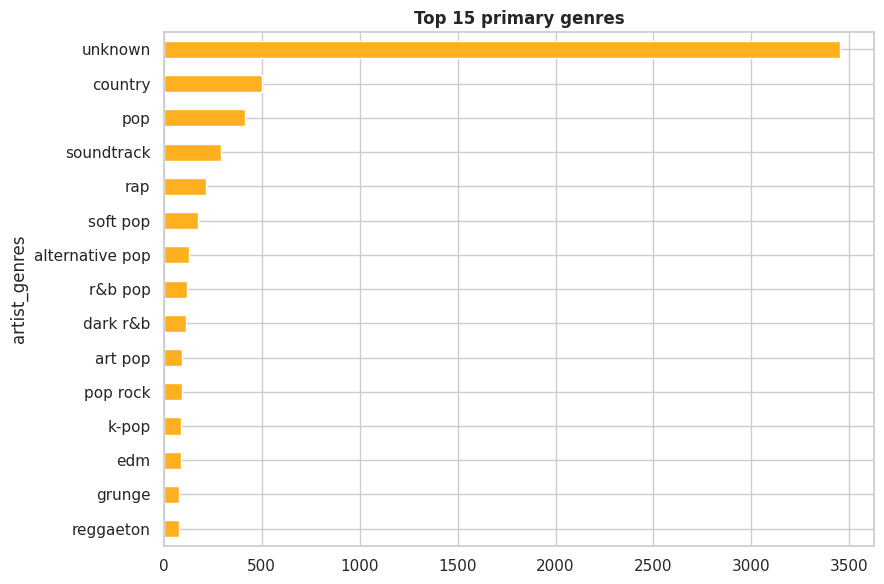

In [12]:
def primary_genre(g):
    if pd.isna(g) or str(g).strip() in ("", "[]"):
        return "unknown"
    return str(g).split(",")[0].strip()

genre_series = df["artist_genres"].apply(primary_genre)
top_genres = genre_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_genres.plot(kind="barh", ax=ax, color="#ffb020")
ax.invert_yaxis()
ax.set_title("Top 15 primary genres")
plt.tight_layout()
plt.show()


**Finding:** `unknown` (missing genre metadata) and `pop` dominate. Genre cardinality
is high (hundreds of unique combinations), so the pipeline buckets genres into the
top-N most frequent primary genres plus an `other` bucket (`FeatureEngineer.top_n_genres`,
configurable in `config.yaml`) before one-hot encoding — this avoids an explosion of sparse
columns.

## 6. Popularity vs. key features

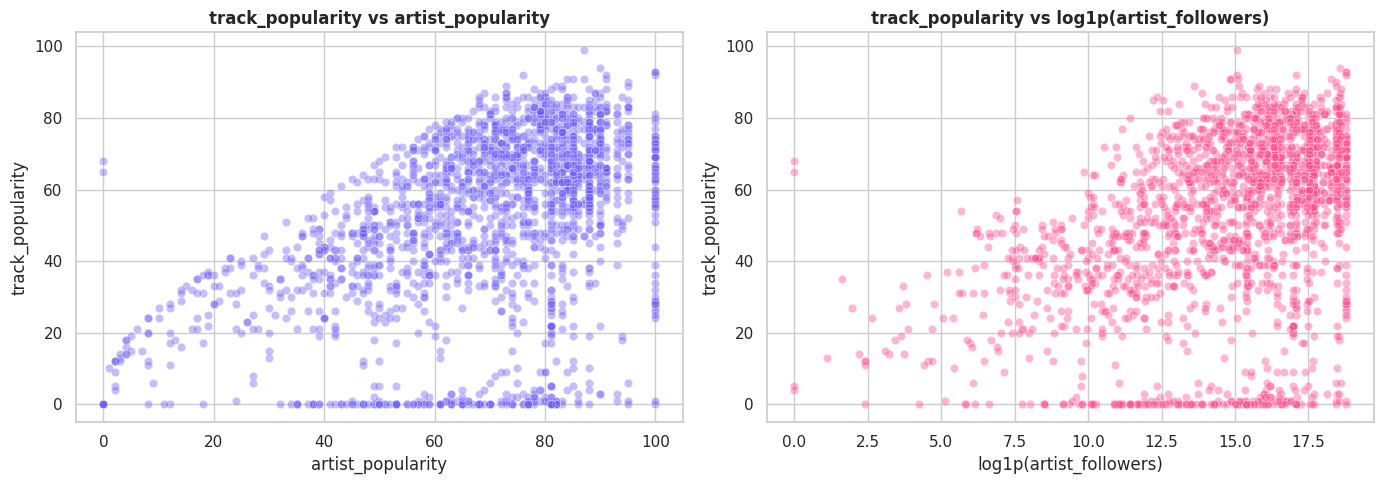

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df.sample(min(2000, len(df)), random_state=42),
                 x="artist_popularity", y="track_popularity", alpha=0.4, ax=axes[0], color="#6d5dfc")
axes[0].set_title("track_popularity vs artist_popularity")

sns.scatterplot(data=df.sample(min(2000, len(df)), random_state=42),
                 x=np.log1p(df["artist_followers"]), y="track_popularity", alpha=0.4, ax=axes[1], color="#ff4d8d")
axes[1].set_title("track_popularity vs log1p(artist_followers)")
axes[1].set_xlabel("log1p(artist_followers)")

plt.tight_layout()
plt.show()


**Finding:** `artist_popularity` shows the clearest positive relationship with
`track_popularity` — unsurprising, since popular artists tend to have popular tracks.
`artist_followers` (log-scaled) shows a similar, slightly noisier, positive trend.
Both are kept as core numeric features.

/tmp/ipykernel_694/3372797895.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="album_type", y="track_popularity", ax=ax, palette="viridis")


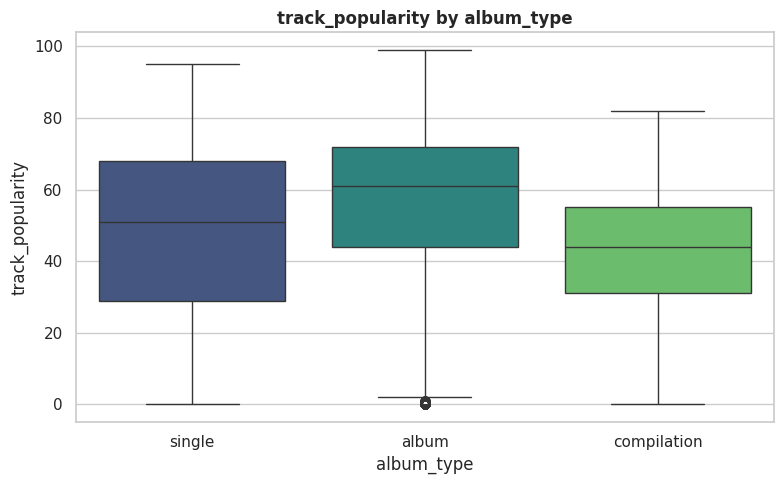

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="album_type", y="track_popularity", ax=ax, palette="viridis")
ax.set_title("track_popularity by album_type")
plt.tight_layout()
plt.show()


### Release recency vs popularity

/tmp/ipykernel_694/3752873077.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=release_year, y=df["track_popularity"], ax=ax, palette="mako")


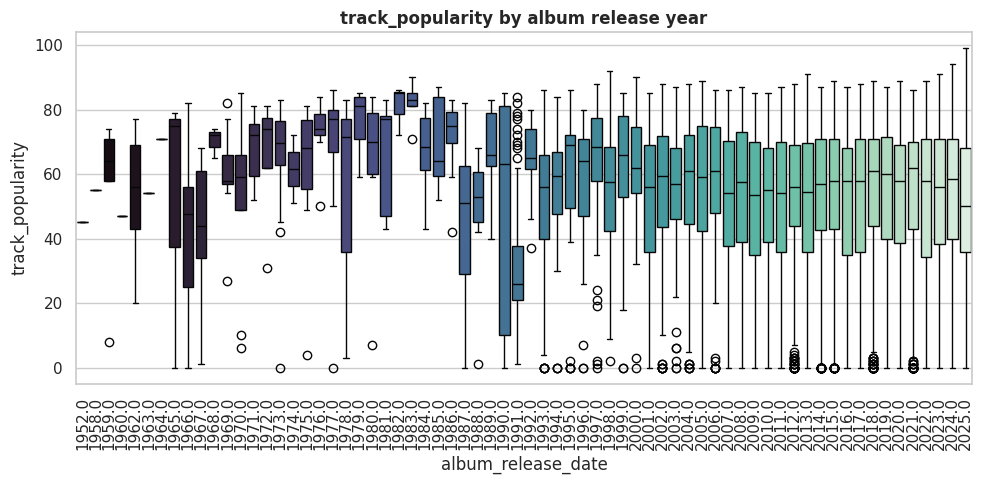

In [15]:
def parse_release_date(s):
    if pd.isna(s):
        return pd.NaT
    s = str(s).strip()
    for fmt in ("%Y-%m-%d", "%Y-%m", "%Y"):
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT

release_dates = df["album_release_date"].apply(parse_release_date)
release_year = release_dates.dt.year

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(x=release_year, y=df["track_popularity"], ax=ax, palette="mako")
ax.set_title("track_popularity by album release year")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


**Finding:** More recently released tracks trend toward higher popularity scores —
Spotify's popularity metric is inherently recency-weighted (it reflects recent play counts
more than lifetime totals). This motivates the `days_since_release`, `release_year` and
`release_month` engineered features.

## 7. Correlation heatmap (numeric + engineered features)

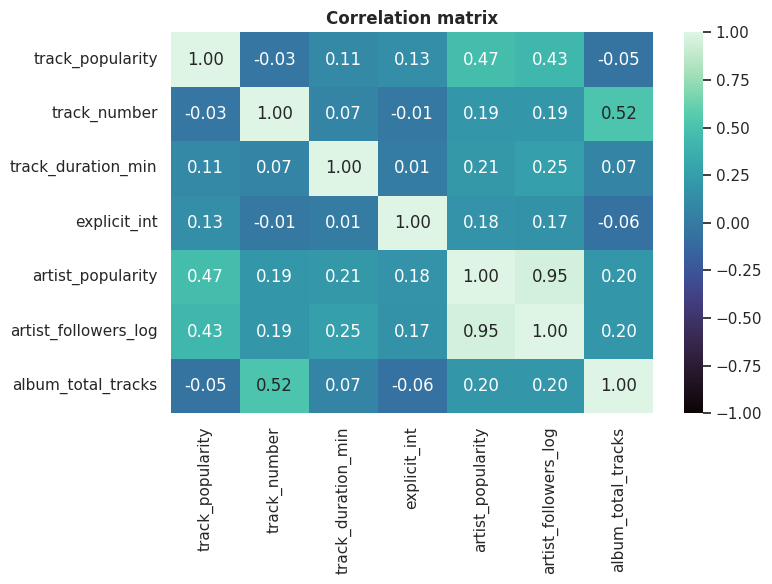

In [16]:
corr_df = df.copy()
corr_df["artist_followers_log"] = np.log1p(corr_df["artist_followers"])
corr_df["track_duration_min"] = corr_df["track_duration_ms"] / 60000
corr_df["explicit_int"] = corr_df["explicit"].astype(int)

corr_cols = ["track_popularity", "track_number", "track_duration_min", "explicit_int",
             "artist_popularity", "artist_followers_log", "album_total_tracks"]

corr = corr_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="mako", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()


## 8. Summary of feature engineering decisions

Based on the analysis above, `src/spotify_popularity/components/feature_engineering.py`
implements:

| Raw column | Engineered feature(s) | Reason |
|---|---|---|
| `album_release_date` | `release_year`, `release_month`, `release_dayofweek`, `days_since_release` | Popularity is recency-weighted; date parsing handles `YYYY`, `YYYY-MM`, `YYYY-MM-DD` formats seen in the data |
| `artist_genres` | `primary_genre` (top-N bucketed + `other`), `genre_count` | High cardinality (800+ raw values) requires bucketing before one-hot encoding |
| `artist_followers` | `artist_followers_log` (log1p) | Heavily right-skewed with extreme outliers |
| `track_name` | `track_name_length` | Weak but free signal; longer/stylised titles occasionally correlate with genre conventions |
| `explicit` | cast to `int` | Boolean → numeric for modeling |
| `track_duration_ms` | `track_duration_min` | More human-interpretable unit for the UI and modeling |

All numeric features additionally pass through `OutlierCapper` (IQR-based clipping),
median imputation and standard scaling; all categorical features pass through
most-frequent imputation and one-hot encoding — implemented in
`SpotifyPreprocessor` (`data_transformation.py`).
